Unione dei dati di traffico aereo (volo) 2024 e 2025

In [2]:
import pandas as pd


# --- PASSO A: Carichiamo e Uniamo i VOLI (Verticale) ---
# Sostituisci con i tuoi nomi file reali
file_voli_24 = "Dati aeroporto/2024 estrazione dati di traffico BLQ.xlsx" # o .xlsx
file_voli_25 = "Dati aeroporto/2025 estrazione dati di traffico BLQ_fino 1007.xlsx"

In [3]:
df_v24 = pd.read_excel(file_voli_24)
df_v25 = pd.read_excel(file_voli_25)

In [4]:
# Incolliamo il 2025 sotto il 2024
df_voli_tot = pd.concat([df_v24, df_v25], ignore_index=True)

Unione dei file degli inquinanti (NO2, C6H6, CO) per avere un unico file per ogni inquinante con dati orari da 2024 a 2025:

In [16]:

print("⏳ Lettura dei file NO2 in corso...")

# 1. Carica i due file (se ti dà errore, metti il percorso completo come r"C:\...\NO2_2024.csv")
df_NO2_2024 = pd.read_csv("Dati aria/NO2_2024.csv")
df_NO2_2025 = pd.read_csv("Dati aria/NO2_2025.csv")

df_C6H6_2024 = pd.read_csv("Dati aria/C6H6_2024.csv")
df_C6H6_2025 = pd.read_csv("Dati aria/C6H6_2025.csv")

df_CO_2024 = pd.read_csv("Dati aria/CO_2024.csv")
df_CO_2025 = pd.read_csv("Dati aria/CO_2025.csv")
# 2. Uniscili uno sotto l'altro
# ignore_index=True serve a rifare la numerazione delle righe da 0 fino alla fine
df_NO2_unito = pd.concat([df_NO2_2024, df_NO2_2025], ignore_index=True)
df_C6H6_unito = pd.concat([df_C6H6_2024, df_C6H6_2025], ignore_index=True)
df_CO_unito = pd.concat([df_CO_2024, df_CO_2025], ignore_index=True)

# 3. Assicuriamoci che siano in perfetto ordine cronologico
df_NO2_unito['data'] = pd.to_datetime(df_NO2_unito['data'])
df_NO2_unito = df_NO2_unito.sort_values('data').reset_index(drop=True)

df_C6H6_unito['data'] = pd.to_datetime(df_C6H6_unito['data'])
df_C6H6_unito = df_C6H6_unito.sort_values('data').reset_index(drop=True)

df_CO_unito['data'] = pd.to_datetime(df_CO_unito['data'])
df_CO_unito = df_CO_unito.sort_values('data').reset_index(drop=True)

# 4. Salva il nuovo mega-file fisico
df_NO2_unito.to_csv("Dati_Aria_Uniti/NO2.csv", index=False)
print("file NO2 creato")

df_NO2_unito.to_csv("Dati_Aria_Uniti/C6H6.csv", index=False)
print("file C6H6 creato")

df_CO_unito.to_csv("Dati_Aria_Uniti/CO.csv", index=False)
print("file CO creato")

⏳ Lettura dei file NO2 in corso...
file NO2 creato
file C6H6 creato
file CO creato


Analisi delle soglie per la classificazione dell'incremento percentuale:

🔍 Analisi statistica per: Dati_Aria_Uniti/C6H6.csv

Ecco come si distribuiscono gli sbalzi (quando ci sono):
count    14793.0
mean        -2.9
std         25.4
min       -266.7
10%        -31.0
25%        -15.4
50%         -2.9
75%         12.8
90%         25.0
max         78.9
Name: Incremento_%, dtype: float64

💡 SUGGERIMENTO PER LE SOGLIE:
Forte Calo: da -infinito a -31.0%
Lieve Calo: da -31.0% a -15.4%
Stabile: da -15.4% a 12.8%
Lieve Aumento: da 12.8% a 25.0%
Forte Aumento: da 25.0% a +infinito


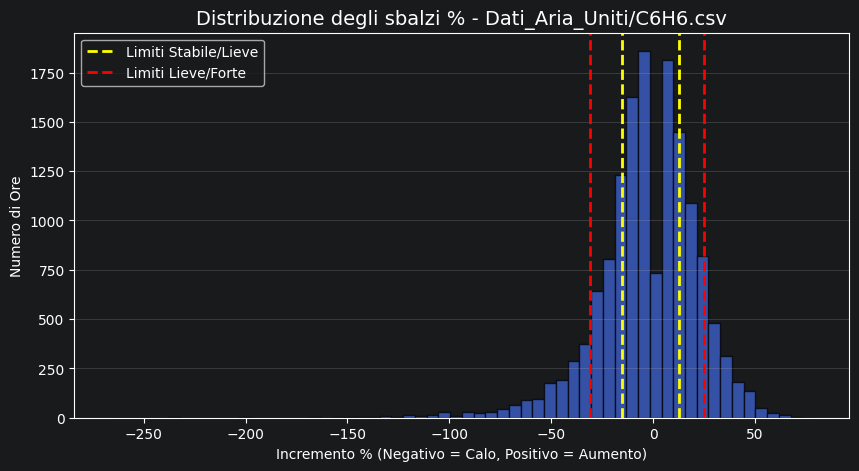

🔍 Analisi statistica per: Dati_Aria_Uniti/CO.csv

Ecco come si distribuiscono gli sbalzi (quando ci sono):
count    7174.0
mean       -6.2
std        39.3
min      -300.0
10%       -50.0
25%       -33.3
50%       -10.0
75%        25.0
90%        33.3
max       100.0
Name: Incremento_%, dtype: float64

💡 SUGGERIMENTO PER LE SOGLIE:
Forte Calo: da -infinito a -50.0%
Lieve Calo: da -50.0% a -33.3%
Stabile: da -33.3% a 25.0%
Lieve Aumento: da 25.0% a 33.3%
Forte Aumento: da 33.3% a +infinito


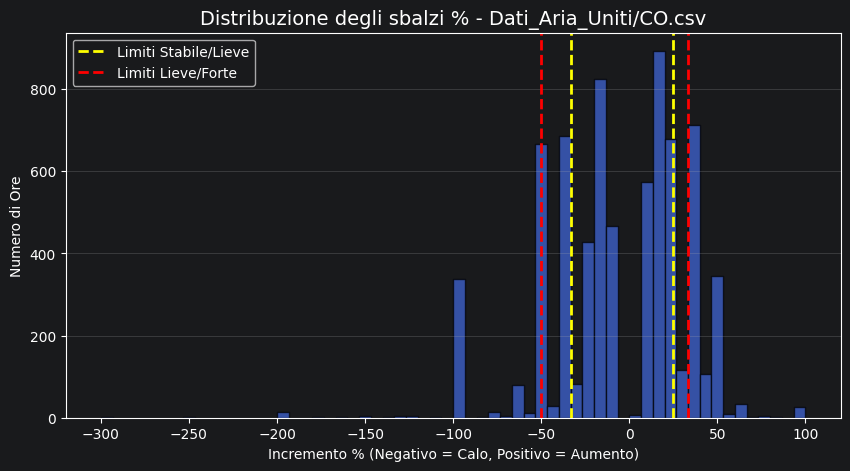

🔍 Analisi statistica per: Dati_Aria_Uniti/NO2.csv

Ecco come si distribuiscono gli sbalzi (quando ci sono):
count    14793.0
mean        -2.9
std         25.4
min       -266.7
10%        -31.0
25%        -15.4
50%         -2.9
75%         12.8
90%         25.0
max         78.9
Name: Incremento_%, dtype: float64

💡 SUGGERIMENTO PER LE SOGLIE:
Forte Calo: da -infinito a -31.0%
Lieve Calo: da -31.0% a -15.4%
Stabile: da -15.4% a 12.8%
Lieve Aumento: da 12.8% a 25.0%
Forte Aumento: da 25.0% a +infinito


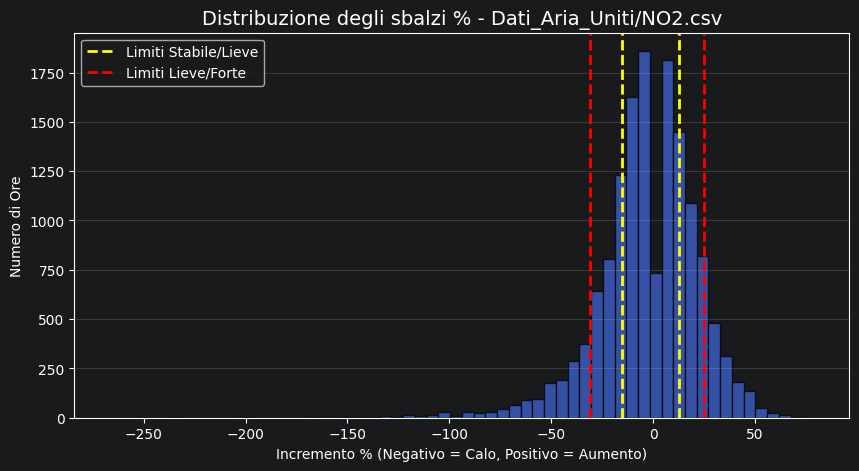

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analizza_soglie_inquinante(file_inquinante):
    print(f"🔍 Analisi statistica per: {file_inquinante}\n")

    # 1. Caricamento e calcolo incremento
    df = pd.read_csv(file_inquinante, usecols=[0, 1])
    df.columns = ['Data_Ora', 'Valore']
    df['Valore'] = pd.to_numeric(df['Valore'], errors='coerce')

    valore_t = df['Valore'].replace(0, np.nan)
    df['Incremento_%'] = ((valore_t - df['Valore'].shift(1)) / valore_t) * 100
    df = df.dropna(subset=['Incremento_%'])

    # 2. Rimuoviamo gli zeri perfetti (le ore piatte non ci aiutano a capire le soglie)
    df_attivo = df[df['Incremento_%'] != 0.0]

    # 3. Stampiamo i percentili chiave
    print("Ecco come si distribuiscono gli sbalzi (quando ci sono):")
    stats = df_attivo['Incremento_%'].describe(percentiles=[0.10, 0.25, 0.75, 0.90])
    print(round(stats, 1))

    print("\n💡 SUGGERIMENTO PER LE SOGLIE:")
    print(f"Forte Calo: da -infinito a {round(stats['10%'], 1)}%")
    print(f"Lieve Calo: da {round(stats['10%'], 1)}% a {round(stats['25%'], 1)}%")
    print(f"Stabile: da {round(stats['25%'], 1)}% a {round(stats['75%'], 1)}%")
    print(f"Lieve Aumento: da {round(stats['75%'], 1)}% a {round(stats['90%'], 1)}%")
    print(f"Forte Aumento: da {round(stats['90%'], 1)}% a +infinito")

    # 4. Creiamo un grafico per vederlo con i nostri occhi
    plt.figure(figsize=(10, 5))
    plt.hist(df_attivo['Incremento_%'], bins=60, color='royalblue', edgecolor='black', alpha=0.7)

    # Disegniamo le linee suggerite
    plt.axvline(stats['25%'], color='yellow', linestyle='dashed', linewidth=2, label='Limiti Stabile/Lieve')
    plt.axvline(stats['75%'], color='yellow', linestyle='dashed', linewidth=2)
    plt.axvline(stats['10%'], color='red', linestyle='dashed', linewidth=2, label='Limiti Lieve/Forte')
    plt.axvline(stats['90%'], color='red', linestyle='dashed', linewidth=2)

    plt.title(f"Distribuzione degli sbalzi % - {file_inquinante}", fontsize=14)
    plt.xlabel("Incremento % (Negativo = Calo, Positivo = Aumento)")
    plt.ylabel("Numero di Ore")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# --- ESEGUI LA FUNZIONE SUL TUO FILE ---
analizza_soglie_inquinante("Dati_Aria_Uniti/C6H6.csv")
analizza_soglie_inquinante("Dati_Aria_Uniti/CO.csv")
analizza_soglie_inquinante("Dati_Aria_Uniti/NO2.csv")

Costruzione dei file finali per il Machine Learning (con classi basate su soglie personalizzate):

In [13]:
import numpy as np

# =====================================================================
# STEP 1: PREPARARE I VOLI E I LAG (Lo facciamo UNA VOLTA sola)
# =====================================================================

# 2. Usa l'orario effettivo e taglia i minuti/secondi per avere l'ora "tonda"
df_voli_tot['BLOCK_TIME'] = pd.to_datetime(df_voli_tot['BLOCK_TIME'])
df_voli_tot['Data_Ora'] = df_voli_tot['BLOCK_TIME'].dt.floor('h')

# 3. Conta quanti voli ci sono per ogni ora
voli_orari = df_voli_tot.groupby('Data_Ora').size().reset_index(name='Voli_t')

# 4. TRUCCO PRO: Se in un'ora di notte ci sono 0 voli, l'ora scompare dal file!
# La ricreiamo artificialmente riempiendo i buchi con 0.
tutte_le_ore = pd.date_range(voli_orari['Data_Ora'].min(), voli_orari['Data_Ora'].max(), freq='h')
voli_orari = voli_orari.set_index('Data_Ora').reindex(tutte_le_ore, fill_value=0).reset_index(names='Data_Ora')

# 5. Crea le Features Temporali
voli_orari['Ora'] = voli_orari['Data_Ora'].dt.hour
voli_orari['Giorno_Settimana'] = voli_orari['Data_Ora'].dt.dayofweek
voli_orari['Mese'] = voli_orari['Data_Ora'].dt.month

# 6. Crea i 24 Lag (il passato)
for i in range(1, 25):
    voli_orari[f'Voli_Lag_{i}'] = voli_orari['Voli_t'].shift(i)

# Togliamo le primissime 24 ore perché non possono avere lag passati
voli_orari = voli_orari.dropna().reset_index(drop=True)
print("✅ Dataset Voli e Lags completato!")


✅ Dataset Voli e Lags completato!


In [20]:
# =====================================================================
# STEP 2: LA FUNZIONE "MACCHINA" PER GLI INQUINANTI
# =====================================================================
def crea_dataset_orario_finale(file_inquinante, df_voli_preparato, soglie_inquinante):
    """
    Legge un file inquinante, calcola classi scientifiche basate su soglie personalizzate, e unisce con i voli.
    """
    print(f"\n⚙️ Elaborazione del file: {file_inquinante}...")

    # 1. Carica l'inquinante
    df_aria = pd.read_csv(file_inquinante, usecols=[0, 1])
    df_aria.columns = ['Data_Ora', 'Valore_Inquinante']
    df_aria['Data_Ora'] = pd.to_datetime(df_aria['Data_Ora'])
    df_aria['Valore_Inquinante'] = pd.to_numeric(df_aria['Valore_Inquinante'], errors='coerce')
    df_aria = df_aria.sort_values('Data_Ora').reset_index(drop=True)

    # 2. Formula dell'incremento percentuale
    valore_t = df_aria['Valore_Inquinante'].replace(0, np.nan)
    valore_t_meno_1 = df_aria['Valore_Inquinante'].shift(1)
    df_aria['Incremento_%'] = ((valore_t - valore_t_meno_1) / valore_t) * 100
    df_aria = df_aria.dropna(subset=['Incremento_%'])

    # 3. Creazione classi usando le SOGLIE PASSATE DALL'ESTERNO
    nomi_classi = ['1_Forte_Calo', '2_Lieve_Calo', '3_Stabile', '4_Lieve_Aumento', '5_Forte_Aumento']

    # Usiamo la variabile 'soglie_inquinante' invece dei numeri fissi
    df_aria['Classe_Incremento'] = pd.cut(df_aria['Incremento_%'], bins=soglie_inquinante, labels=nomi_classi)
    df_aria['Target_ML'] = df_aria['Classe_Incremento'].cat.codes

    # 4. Unisce i voli all'inquinante
    dataset_finale = pd.merge(df_aria, df_voli_preparato, on='Data_Ora', how='inner')

    print(f"✅ Finito! Righe: {len(dataset_finale)}")
    return dataset_finale


# =====================================================================
# STEP 3: CREA I TUOI DATASET!
# =====================================================================

# Ora ti basta una riga per ogni inquinante che hai!
soglie_NO2 = [-float('inf'), -30, -15, 15, 25, float('inf')]
df_ML_NO2 = crea_dataset_orario_finale("Dati_Aria_Uniti/NO2.csv", voli_orari, soglie_NO2)
df_ML_NO2.to_csv("Preprocessed/ppr_NO2.csv", index=False)
print("File NO2 salvato con successo!")

soglie_C6H6 = [-float('inf'), -30, -15, 15, 25, float('inf')]
df_ML_C6H6 = crea_dataset_orario_finale("Dati_Aria_Uniti/C6H6.csv", voli_orari, soglie_C6H6)
df_ML_C6H6.to_csv("Preprocessed/ppr_C6H6.csv", index=False)
print("File C6H6 salvato con successo!")

soglie_CO = [-float('inf'), -50, -30, 25, 35, float('inf')]
df_ML_CO = crea_dataset_orario_finale("Dati_Aria_Uniti/CO.csv", voli_orari, soglie_CO)
df_ML_CO.to_csv("Preprocessed/ppr_CO.csv", index=False)
print("File CO salvato con successo!")


⚙️ Elaborazione del file: Dati_Aria_Uniti/NO2.csv...
✅ Finito! Righe: 12208
File NO2 salvato con successo!

⚙️ Elaborazione del file: Dati_Aria_Uniti/C6H6.csv...
✅ Finito! Righe: 12208
File C6H6 salvato con successo!

⚙️ Elaborazione del file: Dati_Aria_Uniti/CO.csv...
✅ Finito! Righe: 12263
File CO salvato con successo!
